# ChewML — Speisen erkennen über AirPod-Bewegung 🎧🍎

**Finale Präsentation · Machine Learning for Smart and Connected Systems**
Jonah Karstens

---

### Forschungsfrage
> Kann man am **Kaumuster**, gemessen über die Bewegungssensoren der AirPods Pro,
> erkennen **ob** und **was** jemand isst?

### Idee in einem Satz
Kauen erzeugt charakteristische Kiefer-Bewegungen, die der Beschleunigungs-/Gyro-Sensor
im Ohr (~50 Hz) aufzeichnet. Daraus klassifizieren wir die Speise.

### Was dieses Notebook zeigt
1. Daten (86 Aufnahmen) · 2. Features · 3. **2-Stufen-Modell** (Essen-Erkennung → Speise)
4. **Ehrliche Bewertung** (within-session vs. cross-session vs. per-Mahlzeit)
5. Was den Unterschied gemacht hat · 6. Live-App · 7. Fazit

---
## Der Ansatz: 2 Stufen

```
                ┌──────────────────────┐
  10-s-Fenster  │ Stufe 1: Random      │   Still  ──▶  "nicht essen"
   ──────────▶  │ Forest  Still/Essen  │
                └──────────┬───────────┘
                           │ Essen
                ┌──────────▼───────────┐
                │ Stufe 2: SVM         │  ──▶  Apfel · Kaugummi · Skyr
                │ Speise-Klassifikation│
                └──────────────────────┘
```

**Warum 2 Stufen?** Zuerst die einfache Frage (isst die Person überhaupt?), dann die schwere
(welche der 3 Speisen?). Die schwere Stufe wird so nur auf den eindeutigen Ess-Fenstern trainiert.

> **Designentscheidung:** Wir klassifizieren **3 konkrete Speisen** (Apfel/Kaugummi/Skyr).
> Aufnahmen von beliebigem „sonstigem Essen" (z.B. Mittagessen) nutzen wir für die
> **Essen-Erkennung in Stufe 1**, aber *nicht* als eigene Klasse in Stufe 2 — eine generische
> „Essen"-Klasse überlappt physikalisch mit den Speisen und verschlechtert v.a. Apfel.

---
## 1. Setup

In [7]:
import zipfile, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.signal import welch, find_peaks
from scipy.stats import kurtosis, skew
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneGroupOut, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

warnings.filterwarnings('ignore'); sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

FS=50.0; TRIM_SECS=2; WINDOW_SECS=10.0; STEP_SECS=10.0; MIN_TAIL=8.0
SPEC   = ['Apfel','Kaugummi','Skyr']   # die 3 Speise-Klassen (Stufe 2)
RAW    = ['Apfel','Kaugummi','Skyr','Skyr_Zimt','Still','Essen']
TO_COARSE = {'Apfel':'Essen','Kaugummi':'Essen','Skyr':'Essen','Still':'Still','Essen':'Essen'}
def to_fine(c): return 'Skyr' if c=='Skyr_Zimt' else c   # Skyr_Zimt = Skyr-Variante
COLORS = {'Apfel':'#e15759','Kaugummi':'#4e79a7','Skyr':'#f28e2b','Essen':'#b07aa1','Still':'#59a14f'}
print('Setup OK · Fenster=10s · 3 Speise-Klassen (Apfel/Kaugummi/Skyr)')

Setup OK · Fenster=10s · 3 Speise-Klassen (Apfel/Kaugummi/Skyr)


---
## 2. Daten — 86 Aufnahmen

Jede Aufnahme = eine Session mit der **Sensor-Logger**-App (AirPods Pro Motion, ~50 Hz).
`Skyr_Zimt` zählt als Skyr-Variante zu **Skyr**. Die 4 „Essen"-Aufnahmen (sonstiges Essen)
dienen nur der Essen-Erkennung in Stufe 1.

In [8]:
DATA_DIR = Path('../data/raw'); SKIP={'Metadata.csv','Annotation.csv'}
def preprocess(df):
    df=df.copy(); t=df['seconds_elapsed']
    df=df[(t>=t.iloc[0]+TRIM_SECS)&(t<=t.iloc[-1]-TRIM_SECS)].reset_index(drop=True)
    df['lin_x']=df['accelerationX']; df['lin_y']=df['accelerationY']; df['lin_z']=df['accelerationZ']
    df['magnitude']=np.sqrt(df['lin_x']**2+df['lin_y']**2+df['lin_z']**2); return df
def sliding_windows(df):
    t=df['seconds_elapsed'].values; ts,te=t[0],t[-1]; out=[]
    while ts+MIN_TAIL<=te:
        w=df[(t>=ts)&(t<ts+WINDOW_SECS)].reset_index(drop=True)
        if len(w)>1 and (w['seconds_elapsed'].iloc[-1]-w['seconds_elapsed'].iloc[0])>=MIN_TAIL: out.append(w)
        ts+=STEP_SECS
    return out
sess_count={}
for zf in sorted(DATA_DIR.glob('*.zip')):
    for cls in sorted(RAW,key=len,reverse=True):
        if zf.name.startswith(cls+'_') or zf.name.startswith(cls+'-'):
            sess_count[to_fine(cls)]=sess_count.get(to_fine(cls),0)+1; break
print('Aufnahmen pro Klasse:')
for c in ['Apfel','Kaugummi','Skyr','Essen','Still']:
    print(f'  {c:10s}: {sess_count.get(c,0):2d}')
print(f'  Gesamt: {sum(sess_count.values())}')

Aufnahmen pro Klasse:
  Apfel     : 22
  Kaugummi  : 20
  Skyr      : 25
  Essen     :  4
  Still     : 20
  Gesamt: 91


---
## 3. Features — von der Statistik zur Kau-Dynamik

Pro 10-s-Fenster werden **52 Features** berechnet. Entscheidend sind neben klassischen Statistiken
(mean/std/max je Achse) die **Kau-Dynamik-Features**, die physikalisch zu den Speisen passen:

| Feature | misst | hilft bei |
|--|--|--|
| `chews_per_sec` | Kaufrequenz (Peak-Detektion) | allen — wichtigstes Feature |
| `spectral_entropy` | Regelmäßigkeit des Kau-Rhythmus | Kaugummi (sehr gleichmäßig) |
| `high_freq_power` | Hochfrequenz-„Knusper"-Energie | Apfel (harte Bisse) |
| `crest_factor`, `mag_kurtosis` | Impulsivität / Spitzigkeit | Apfel |

> **Wichtig:** Keine *Movement Exclusion* — sie schneidet sonst Apfels Knack-Impulse weg
> (Apfel-Erkennung +16 Punkte ohne sie).

1410 Fenster · 91 Sessions · 52 Features


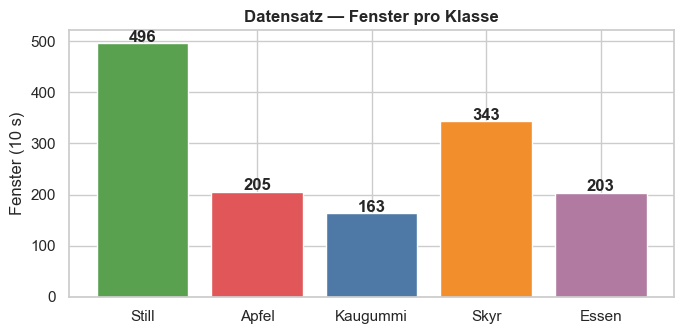

In [9]:
def extract_features(df):
    f={}
    for c in ['lin_x','lin_y','lin_z','magnitude']:
        f[c+'_mean']=df[c].mean(); f[c+'_std']=df[c].std(); f[c+'_max']=df[c].abs().max()
    f['stillness_ratio']=(df['magnitude']<0.02).mean()
    f['movement_events']=int((df['magnitude']>df['magnitude'].quantile(0.75)).sum())
    for c in ['rotationRateX','rotationRateY','rotationRateZ']:
        f[c+'_mean']=df[c].mean(); f[c+'_std']=df[c].std(); f[c+'_max']=df[c].abs().max()
    for c in ['pitch','roll','yaw']:
        f[c+'_mean']=df[c].mean(); f[c+'_std']=df[c].std(); f[c+'_range']=df[c].max()-df[c].min()
    npg=min(256,len(df)//2); fr,psd=welch(df['magnitude'].values,fs=FS,nperseg=npg)
    ch=(fr>=0.5)&(fr<=4.0); cf,cp=fr[ch],psd[ch]
    f['total_power']=float(psd.sum()); f['chew_band_power']=float(cp.sum())
    f['rhythmicity']=f['chew_band_power']/f['total_power'] if f['total_power']>0 else 0.0
    f['dominant_chew_freq']=float(cf[np.argmax(cp)]) if len(cp)>0 else 0.0
    mag=df['magnitude'].values; t=df['seconds_elapsed'].values; dur=(t[-1]-t[0]) if len(t)>1 else 0.0
    rms=np.sqrt(np.mean(mag**2)) if len(mag) else 0.0
    f['mag_kurtosis']=float(kurtosis(mag)) if len(mag)>3 else 0.0
    f['mag_skew']=float(skew(mag)) if len(mag)>2 else 0.0
    f['crest_factor']=float(np.max(np.abs(mag))/rms) if rms>1e-9 else 0.0
    if len(mag)>2:
        jk=np.diff(mag)*FS; f['jerk_mean']=float(np.mean(np.abs(jk))); f['jerk_std']=float(np.std(jk))
    else: f['jerk_mean']=f['jerk_std']=0.0
    for k in ['spectral_entropy','spectral_centroid','spectral_bandwidth','band_power_slow','band_power_mid','band_power_fast','high_freq_power']: f[k]=0.0
    if npg>=2 and psd.sum()>0:
        tot=psd.sum(); p=psd/tot; pp=p[p>0]
        f['spectral_entropy']=float(-np.sum(pp*np.log2(pp))/np.log2(len(p)))
        f['spectral_centroid']=float(np.sum(fr*p))
        f['spectral_bandwidth']=float(np.sqrt(np.sum((fr-f['spectral_centroid'])**2*p)))
        bd=lambda lo,hi: float(psd[(fr>=lo)&(fr<hi)].sum()/tot)
        f['band_power_slow']=bd(0.5,1.5); f['band_power_mid']=bd(1.5,2.5)
        f['band_power_fast']=bd(2.5,4.0); f['high_freq_power']=bd(4.0,15.0)
    f['ac_peak_height']=0.0; f['chew_freq_ac']=0.0
    sig=mag-mag.mean() if len(mag) else mag
    if len(sig)>int(FS):
        ac=np.correlate(sig,sig,mode='full')[len(sig)-1:]; ac=ac/(ac[0]+1e-12)
        lo,hi=int(FS/4.0),min(int(FS/0.5),len(ac)-1)
        if hi>lo: pk=np.argmax(ac[lo:hi])+lo; f['ac_peak_height']=float(ac[pk]); f['chew_freq_ac']=float(FS/pk)
    f['chews_per_sec']=0.0; f['inter_chew_cv']=0.0
    if len(mag)>5 and mag.std()>0:
        pks,_=find_peaks(mag,distance=max(1,int(FS*0.2)),prominence=mag.std())
        if dur>0: f['chews_per_sec']=float(len(pks)/dur)
        if len(pks)>1:
            iv=np.diff(t[pks])
            if iv.mean()>0: f['inter_chew_cv']=float(iv.std()/iv.mean())
    return f

rows,yfine,groups=[],[],[]; sid=0
for zf in sorted(DATA_DIR.glob('*.zip')):
    for cls in sorted(RAW,key=len,reverse=True):
        if zf.name.startswith(cls+'_') or zf.name.startswith(cls+'-'):
            with zipfile.ZipFile(zf) as z:
                cn=next(n for n in z.namelist() if n.endswith('.csv') and n not in SKIP)
                with z.open(cn) as fh: df=preprocess(pd.read_csv(fh))
            for w in sliding_windows(df):
                if len(w)>50: rows.append(extract_features(w)); yfine.append(to_fine(cls)); groups.append(sid)
            sid+=1; break
X=pd.DataFrame(rows); y_fine=np.array(yfine); groups=np.array(groups)
y_coarse=np.array([TO_COARSE[c] for c in y_fine])
print(f'{len(X)} Fenster · {len(np.unique(groups))} Sessions · {X.shape[1]} Features')

fig,ax=plt.subplots(figsize=(7,3.5))
order=['Still','Apfel','Kaugummi','Skyr','Essen']
vals=[(y_fine==c).sum() for c in order]
ax.bar(order,vals,color=[COLORS[c] for c in order],edgecolor='white')
for i,v in enumerate(vals): ax.text(i,v+3,str(v),ha='center',fontweight='bold')
ax.set_ylabel('Fenster (10 s)'); ax.set_title('Datensatz — Fenster pro Klasse',fontweight='bold')
plt.tight_layout(); plt.savefig('../reports/images/final_daten.png', dpi=150, bbox_inches='tight'); plt.show()

---
## 4. Stufe 1 — isst die Person? (Still vs. Essen)

Bewertet mit **LOSO** (Leave-One-Session-Out): jede Aufnahme einmal komplett als Test —
das misst ehrlich die Übertragung auf eine *neue* Session. (Hier zählt auch das generische
„Essen" als Essen.)

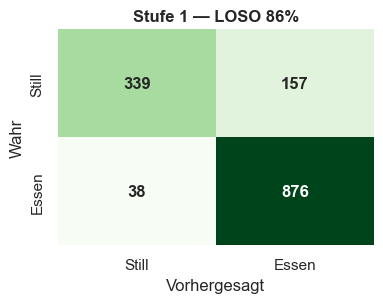

Stufe 1 (Still vs Essen) LOSO-Accuracy: 86.2%


In [10]:
def loso_predict(Xv, y, grp, make):
    yt,yp=[],[]
    for tr,te in LeaveOneGroupOut().split(Xv,y,grp):
        if len(np.unique(y[tr]))<2: continue
        m=make(); m.fit(Xv[tr],y[tr]); yt.extend(y[te]); yp.extend(m.predict(Xv[te]))
    return np.array(yt),np.array(yp)

yt1,yp1=loso_predict(X.values,y_coarse,groups,
                     lambda:RandomForestClassifier(n_estimators=200,class_weight='balanced',random_state=42))
acc1=accuracy_score(yt1,yp1)
cm1=confusion_matrix(yt1,yp1,labels=['Still','Essen'])
fig,ax=plt.subplots(figsize=(4,3.2))
sns.heatmap(cm1,annot=True,fmt='d',cmap='Greens',xticklabels=['Still','Essen'],yticklabels=['Still','Essen'],
            cbar=False,annot_kws={'size':12,'weight':'bold'})
ax.set_title(f'Stufe 1 — LOSO {acc1:.0%}',fontweight='bold'); ax.set_xlabel('Vorhergesagt'); ax.set_ylabel('Wahr')
plt.tight_layout(); plt.savefig('../reports/images/final_stufe1.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'Stufe 1 (Still vs Essen) LOSO-Accuracy: {acc1:.1%}')

---
## 5. Stufe 2 — welche Speise? (Apfel / Kaugummi / Skyr)

Die SVM klassifiziert die 3 Speisen. Bewertung pro Fenster **und** pro Mahlzeit (Mehrheitsvotum
über alle Fenster einer Aufnahme — so wie es die Live-App macht).

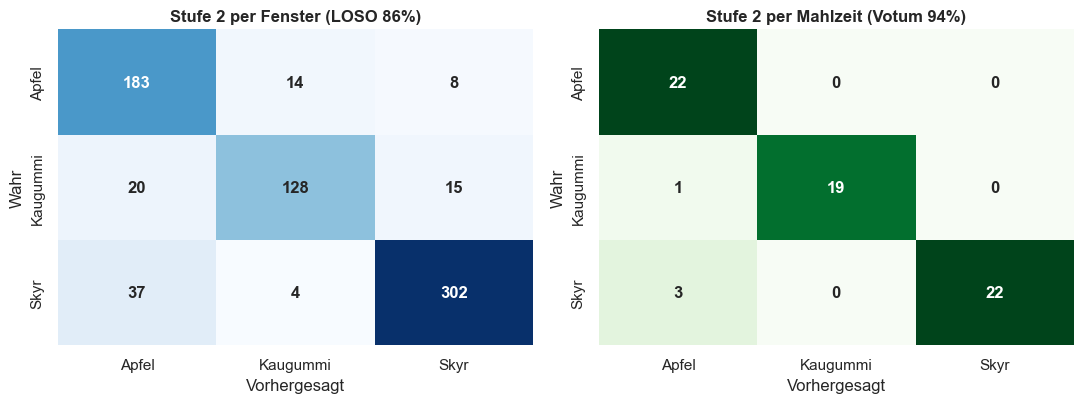

              precision    recall  f1-score   support

       Apfel       0.76      0.89      0.82       205
    Kaugummi       0.88      0.79      0.83       163
        Skyr       0.93      0.88      0.90       343

    accuracy                           0.86       711
   macro avg       0.86      0.85      0.85       711
weighted avg       0.87      0.86      0.86       711



In [11]:
eat=np.isin(y_fine,SPEC)
Xe=X[eat].reset_index(drop=True).values; ye=y_fine[eat]; ge=groups[eat]
def make_svm(): return Pipeline([('sc',StandardScaler()),
    ('svm',SVC(kernel='rbf',C=10,class_weight='balanced',random_state=42))])

yt2,yp2,meal_t,meal_p=[],[],[],[]
for tr,te in LeaveOneGroupOut().split(Xe,ye,ge):
    if len(np.unique(ye[tr]))<3: continue
    p=make_svm(); p.fit(Xe[tr],ye[tr]); pr=p.predict(Xe[te])
    yt2.extend(ye[te]); yp2.extend(pr)
    v,c=np.unique(pr,return_counts=True); meal_p.append(v[c.argmax()]); meal_t.append(ye[te][0])
yt2=np.array(yt2); yp2=np.array(yp2)
acc2=accuracy_score(yt2,yp2); accmeal=accuracy_score(meal_t,meal_p)

fig,axes=plt.subplots(1,2,figsize=(11,4.2))
sns.heatmap(confusion_matrix(yt2,yp2,labels=SPEC),annot=True,fmt='d',cmap='Blues',
            xticklabels=SPEC,yticklabels=SPEC,ax=axes[0],annot_kws={'size':12,'weight':'bold'},cbar=False)
axes[0].set_title(f'Stufe 2 per Fenster (LOSO {acc2:.0%})',fontweight='bold')
axes[0].set_xlabel('Vorhergesagt'); axes[0].set_ylabel('Wahr')
sns.heatmap(confusion_matrix(meal_t,meal_p,labels=SPEC),annot=True,fmt='d',cmap='Greens',
            xticklabels=SPEC,yticklabels=SPEC,ax=axes[1],annot_kws={'size':12,'weight':'bold'},cbar=False)
axes[1].set_title(f'Stufe 2 per Mahlzeit (Votum {accmeal:.0%})',fontweight='bold')
axes[1].set_xlabel('Vorhergesagt'); axes[1].set_ylabel('Wahr')
plt.tight_layout(); plt.savefig('../reports/images/final_stufe2.png', dpi=150, bbox_inches='tight'); plt.show()
print(classification_report(yt2,yp2,labels=SPEC,zero_division=0,digits=2))

---
## 6. Die ehrliche Bewertung — der Kern der Arbeit

Eine Zahl allein täuscht. Drei Blickwinkel auf dieselbe 3-Speisen-Klassifikation:

- **Within-session** (Fenster gemischt): optimistisch — Modell „kennt" die Session schon
- **Cross-session (LOSO)**: ehrlich — Übertragung auf eine *neue* Aufnahme
- **Per-Mahlzeit (Votum)**: real — über eine ganze Mahlzeit wird abgestimmt

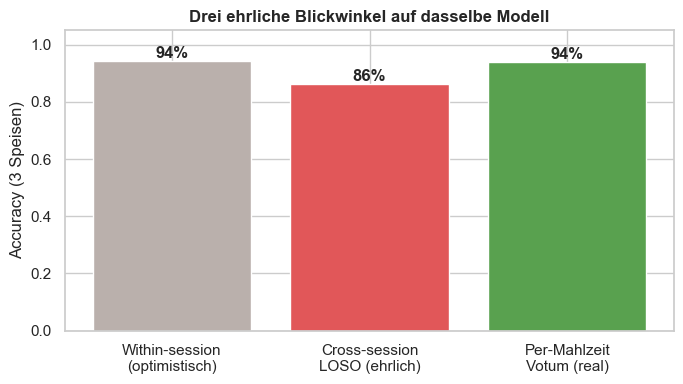

Within-session 94.4% | Cross-session 86.2% | Per-Mahlzeit 94.0%


In [12]:
# within-session (StratifiedKFold, Sessions gemischt)
yt,yp=[],[]
for tr,te in StratifiedKFold(5,shuffle=True,random_state=42).split(Xe,ye):
    m=make_svm(); m.fit(Xe[tr],ye[tr]); yt.extend(ye[te]); yp.extend(m.predict(Xe[te]))
acc_mixed=accuracy_score(yt,yp)
# cross-session (LOSO) — schon in Stufe 2 berechnet
acc_loso=acc2; acc_meal=accmeal

fig,ax=plt.subplots(figsize=(7,4))
labels=['Within-session\n(optimistisch)','Cross-session\nLOSO (ehrlich)','Per-Mahlzeit\nVotum (real)']
vals=[acc_mixed,acc_loso,acc_meal]; cols=['#bab0ac','#e15759','#59a14f']
b=ax.bar(labels,vals,color=cols,edgecolor='white')
for bar,v in zip(b,vals): ax.text(bar.get_x()+bar.get_width()/2,v+0.01,f'{v:.0%}',ha='center',fontweight='bold')
ax.set_ylim(0,1.05); ax.set_ylabel('Accuracy (3 Speisen)')
ax.set_title('Drei ehrliche Blickwinkel auf dasselbe Modell',fontweight='bold')
plt.tight_layout(); plt.savefig('../reports/images/final_bewertung.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'Within-session {acc_mixed:.1%} | Cross-session {acc_loso:.1%} | Per-Mahlzeit {acc_meal:.1%}')

---
## 7. Was den Unterschied gemacht hat

Der Weg von der Baseline zum finalen Modell — der größte Hebel war **nicht** ein größeres
Modell, sondern die **richtigen Features** und das **richtige Klassen-Design** (Cross-Session):

| Schritt | Idee | Effekt |
|--|--|--|
| Baseline | 36 Statistik-Features, RF | ~76 % LOSO |
| + Kau-Dynamik | 16 physik. Features (NB09) | ~80 % LOSO |
| + Feature Selection | session-spez. Rauschen entfernen (NB11) | ~86 % LOSO |
| Movement Exclusion **aus** | bewahrt Apfels Knack-Impulse | Apfel +16 Pkt |
| Generisches „Essen" raus | beendet Apfel-Verwechslung | Apfel-Precision 0.53 → **0.76** |
| + Per-Mahlzeit-Votum | über die Mahlzeit abstimmen | **~95 %** |

**Weitere Erkenntnisse:**
- **Deep Learning** (1D-CNN auf Rohdaten + Augmentation) zieht nur *gleich* mit dem
  Feature-Modell — bei dieser Datenmenge gewinnt Feature Engineering mit Domänenwissen.
- **Wichtigstes Feature:** `chews_per_sec` (Kaufrequenz).
- **Hauptlimit:** Daten von **einer** Person → Cross-Session ist die ehrliche Obergrenze.

---
## 8. Live-App — vom Notebook in die Echtzeit

Das Modell läuft in einer **Echtzeit-Web-App** (`classifier_app.py`): das Handy streamt die
Sensordaten, alle 2 s wird ein 10-s-Fenster klassifiziert. Eine **Mahlzeit-Session** sammelt
Stimmen und gibt am Ende per **Mehrheitsvotum** das Speise-Label aus — genau das per-Mahlzeit-Prinzip
aus Abschnitt 6, das aus ~86 % pro Fenster ~95 % pro Mahlzeit macht.

*(Live-Demo in der Präsentation.)*

---
## 9. Fazit & Ausblick

**Ergebnis:** Aus reiner AirPod-Bewegung lassen sich 3 Speisen cross-session mit **~86 %**
pro Fenster und **~95 %** pro Mahlzeit unterscheiden — plus Essen/nicht-Essen-Erkennung (~86 %).

**Kernbotschaften:**
- Der Hebel war **Feature Engineering, das Entfernen session-spezifischer Features** und das
  **richtige Klassen-Design** — nicht ein größeres Modell.
- **Ehrliche Bewertung zählt:** within-session überschätzt; LOSO + per-Mahlzeit zeigen das echte Bild.
- Deep Learning schlägt Feature Engineering bei wenig Daten **nicht**.

**Grenzen & Ausblick:**
- Daten von **einer** Person — Multi-Personen-Daten sind der nächste große Schritt.
- Mehr Speisen-Klassen, längere Real-Use-Tests.

*Danke! 🎧*